# NASA SBDB Asteroid Data Downloader
For Potentially Hazardous Asteroid (PHA) Classification

In [1]:
!pip install astroquery tqdm pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 104.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 45.3 MB/s eta 0:00:00


In [2]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, roc_curve, auc
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from astroquery.jplsbdb import SBDB
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

print("TensorFlow version:", tf.__version__)
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))


TensorFlow version: 2.19.0
Num GPUs Available: 0


In [ ]:
# Convert JSON to Python dictionary (extracts key parameters)
def json_to_dict(asteroid_object, asteroid_orbit, asteroid_phys):
    try:
        asteroid_dict = {
            'des': asteroid_object.get('des'),
            'pha': asteroid_object.get('pha'),
            'neo': asteroid_object.get('neo'),
            'e': asteroid_orbit['elements']['e'],
            'a': asteroid_orbit['elements']['a'].value,
            'q': asteroid_orbit['elements']['q'].value,
            'i': asteroid_orbit['elements']['i'].value,
            'om': asteroid_orbit['elements']['om'].value,
            'w': asteroid_orbit['elements']['w'].value,
            'ma': asteroid_orbit['elements']['ma'].value,
            'tp': asteroid_orbit['elements']['tp'].value,
            'per': asteroid_orbit['elements']['per'].value,
            'n': asteroid_orbit['elements']['n'].value,
            'ad': asteroid_orbit['elements']['ad'].value,
            'moid': asteroid_orbit['moid'].value,
            'moid_jup': asteroid_orbit['moid_jup'].value,
            't_jup': asteroid_orbit.get('t_jup'),
            'rms': asteroid_orbit.get('rms'),
            'H': asteroid_phys.get('H')
        }
        return asteroid_dict
    except Exception:
        return None


In [ ]:
# Generate list of letters (A–Z excluding I)
def get_letter(start, end):
    letter_list = [chr(i) for i in range(ord(start), ord(end) + 1)]
    if 'I' in letter_list:
        letter_list.remove('I')
    return letter_list


In [ ]:
# Fetch asteroid designations for given years
def request_asteroids_des(year_list):
    first_letter = get_letter('A', 'Y')
    second_letter = get_letter('A', 'Z')
    asteroids_list = []

    for year in year_list:
        print(f"🔎 Searching asteroids from {year}...")
        for first in first_letter:
            for second in second_letter:
                try:
                    query = f'{year} {first}{second}*'
                    sbdb = SBDB.query(query, neo_only=True)

                    if 'list' in sbdb:
                        asteroids_list.extend(sbdb['list']['pdes'])
                    else:
                        asteroids_list.append(sbdb['object']['des'])
                except Exception:
                    continue
    return asteroids_list


In [ ]:
# Fetch full asteroid data for each designation
def request_asteroids_data(asteroids_des):
    asteroids_list = []
    for asteroid in tqdm(asteroids_des, desc='📡 Downloading asteroid data'):
        try:
            sbdb = SBDB.query(f'{asteroid}', phys=True)
            asteroid_object = sbdb['object']
            asteroid_orbit = sbdb['orbit']
            asteroid_phys = sbdb['phys_par']

            asteroid_dict = json_to_dict(asteroid_object, asteroid_orbit, asteroid_phys)
            if asteroid_dict:
                asteroids_list.append(asteroid_dict)

        except Exception:
            continue

    asteroids_df = pd.DataFrame(asteroids_list)
    return asteroids_df


In [ ]:
years = [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

# Step 1: Get asteroid designations
asteroid_names = request_asteroids_des(years)
print(f"✅ Found {len(asteroid_names)} asteroids.")

# Step 2: Get detailed asteroid data
asteroids_df = request_asteroids_data(asteroid_names)

# Step 3: Save to CSV
asteroids_df.to_csv("pha_asteroids_dataset.csv", index=False)
print("💾 Dataset saved as 'pha_asteroids_dataset.csv'")

# Step 4: Preview the data
asteroids_df.head()


In [ ]:
years = [2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014]

# Step 1: Get asteroid designations
asteroid_names = request_asteroids_des(years)
print(f"✅ Found {len(asteroid_names)} asteroids.")

# Step 2: Get detailed asteroid data
asteroids_df_2000_2014 = request_asteroids_data(asteroid_names)

# Step 3: Save to CSV
asteroids_df_2000_2014.to_csv("pha_asteroids_dataset_2000_2014.csv", index=False)
print("💾 Dataset saved as 'pha_asteroids_dataset_2000_2014.csv'")

# Step 4: Preview the data
asteroids_df_2000_2014.head()


🔎 Searching asteroids from 2000...
🔎 Searching asteroids from 2001...
🔎 Searching asteroids from 2002...
🔎 Searching asteroids from 2003...
🔎 Searching asteroids from 2004...
🔎 Searching asteroids from 2005...
🔎 Searching asteroids from 2006...
🔎 Searching asteroids from 2007...
🔎 Searching asteroids from 2008...
🔎 Searching asteroids from 2009...
🔎 Searching asteroids from 2010...
🔎 Searching asteroids from 2011...
🔎 Searching asteroids from 2012...
🔎 Searching asteroids from 2013...
🔎 Searching asteroids from 2014...
✅ Found 11487 asteroids.


📡 Downloading asteroid data: 100%|██████████| 11487/11487 [18:25<00:00, 10.39it/s]


💾 Dataset saved as 'pha_asteroids_dataset_2000_2014.csv'


,des,pha,neo,e,a,q,i,om,w,ma,tp,per,n,ad,moid,moid_jup,t_jup,rms,H
0,2000 AA6,True,True,0.519,1.290,0.618,2.03,280.0,288.0,219.0,2461209.531,533.0,0.676,1.95,0.00766,3.01,4.894,0.4,22.44
1,137911,False,True,0.495,2.300,1.160,3.76,29.3,312.0,158.0,2460440.958,1280.0,0.282,3.44,0.16400,1.97,3.413,0.57,17.75
2,2000 AB6,False,True,0.476,1.790,0.936,3.80,283.0,134.0,315.0,2461109.545,872.0,0.413,2.64,0.01530,2.75,3.940,0.45,22.40
3,422686,True,True,0.287,0.854,0.609,4.70,101.0,188.0,115.0,2460908.637,288.0,1.250,1.10,0.04620,4.03,6.869,0.42,21.63
4,331510,False,True,0.552,2.720,1.220,11.90,120.0,280.0,305.0,2461249.314,1640.0,0.220,4.22,0.31900,1.50,3.093,0.62,17.65


In [ ]:
# combining two datasets

# Step 1: Read both CSV files
df_2000_2014 = pd.read_csv("pha_asteroids_dataset_2000_2014.csv")
df_2015_2025 = pd.read_csv("pha_asteroids_dataset_2015_2025.csv")

# Step 2: Combine them
combined_df = pd.concat([df_2000_2014, df_2015_2025], ignore_index=True)

# Step 3: Save the combined dataset
combined_df.to_csv("pha_asteroids_dataset_2000_2025.csv", index=False)

print("💾 Combined dataset saved as 'pha_asteroids_dataset_2000_2025.csv'")

# Step 4: Optional — Preview first few rows
print(combined_df.head())


💾 Combined dataset saved as 'pha_asteroids_dataset_2000_2025.csv'
        des    pha   neo      e      a      q      i     om      w     ma  \
0  2000 AA6   True  True  0.519  1.290  0.618   2.03  280.0  288.0  219.0   
1    137911  False  True  0.495  2.300  1.160   3.76   29.3  312.0  158.0   
2  2000 AB6  False  True  0.476  1.790  0.936   3.80  283.0  134.0  315.0   
3    422686   True  True  0.287  0.854  0.609   4.70  101.0  188.0  115.0   
4    331510  False  True  0.552  2.720  1.220  11.90  120.0  280.0  305.0   

            tp     per      n    ad     moid  moid_jup  t_jup   rms      H  
0  2461209.531   533.0  0.676  1.95  0.00766      3.01  4.894  0.40  22.44  
1  2460440.958  1280.0  0.282  3.44  0.16400      1.97  3.413  0.57  17.75  
2  2461109.545   872.0  0.413  2.64  0.01530      2.75  3.940  0.45  22.40  
3  2460908.637   288.0  1.250  1.10  0.04620      4.03  6.869  0.42  21.63  
4  2461249.314  1640.0  0.220  4.22  0.31900      1.50  3.093  0.62  17.65  


# Exploratory Data Analysis

In [3]:
import os
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
directory_files = os.listdir('/content/drive/MyDrive/Colab Notebooks/CM4609 - Individual Research Project/Dataset/')
print(directory_files)

['pha_asteroids_dataset_2015_2025.csv', 'pha_asteroids_dataset_2000_2014.csv', 'pha_asteroids_dataset_2000_2025.csv']


# **2000-2025 ASTEROID DATA**

In [5]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/CM4609 - Individual Research Project/Dataset/pha_asteroids_dataset_2000_2025.csv")
print(df)

            des    pha   neo      e      a      q      i     om      w  \
0      2000 AA6   True  True  0.519  1.290  0.618   2.03  280.0  288.0   
1        137911  False  True  0.495  2.300  1.160   3.76   29.3  312.0   
2      2000 AB6  False  True  0.476  1.790  0.936   3.80  283.0  134.0   
3        422686   True  True  0.287  0.854  0.609   4.70  101.0  188.0   
4        331510  False  True  0.552  2.720  1.220  11.90  120.0  280.0   
...         ...    ...   ...    ...    ...    ...    ...    ...    ...   
38881  2025 UZ1  False  True  0.437  1.670  0.940   7.55   27.8  319.0   
38882  2025 UZ2  False  True  0.139  1.340  1.150  15.90  199.0  160.0   
38883  2025 UZ4  False  True  0.458  1.720  0.933  25.60   16.5  343.0   
38884  2025 UZ6  False  True  0.701  2.050  0.614   8.78  298.0  344.0   
38885  2025 UZ7  False  True  0.272  0.922  0.672   2.07   35.2  237.0   

           ma           tp     per      n    ad      moid  moid_jup  t_jup  \
0      219.00  2461209.531   533.

In [6]:
print("Dataset Shape:", df.shape)
print("\n--- Data Types ---")
print(df.dtypes)
print("\n--- Missing Values ---")
print(df.isnull().sum().sort_values(ascending=False).head(20))


Dataset Shape: (38886, 19)

--- Data Types ---
des          object
pha            bool
neo            bool
e           float64
a           float64
q           float64
i           float64
om          float64
w           float64
ma          float64
tp          float64
per         float64
n           float64
ad          float64
moid        float64
moid_jup    float64
t_jup       float64
rms         float64
H           float64
dtype: object

--- Missing Values ---
H           29
pha          0
des          0
neo          0
e            0
q            0
a            0
om           0
w            0
ma           0
i            0
tp           0
per          0
ad           0
n            0
moid         0
moid_jup     0
t_jup        0
rms          0
dtype: int64


In [7]:
target_col = None
for col in ["pha", "is_pha", "PHA", "potentially_hazardous"]:
    if col in df.columns:
        target_col = col
        break
if target_col is None:
    raise ValueError("PHA target column not found!")

# Encode target if it's text
if df[target_col].dtype == bool:
  df['pha'] = df['pha'].astype(int)
  df['neo'] = df['neo'].astype(int)


In [8]:
df.head(10)

,des,pha,neo,e,a,q,i,om,w,ma,tp,per,n,ad,moid,moid_jup,t_jup,rms,H
0,2000 AA6,1,1,0.519,1.290,0.618,2.03,280.0,288.0,219.0,2461209.531,533.0,0.676,1.95,0.00766,3.01,4.894,0.40,22.44
1,137911,0,1,0.495,2.300,1.160,3.76,29.3,312.0,158.0,2460440.958,1280.0,0.282,3.44,0.16400,1.97,3.413,0.57,17.75
2,2000 AB6,0,1,0.476,1.790,0.936,3.80,283.0,134.0,315.0,2461109.545,872.0,0.413,2.64,0.01530,2.75,3.940,0.45,22.40
3,422686,1,1,0.287,0.854,0.609,4.70,101.0,188.0,115.0,2460908.637,288.0,1.250,1.10,0.04620,4.03,6.869,0.42,21.63
4,331510,0,1,0.552,2.720,1.220,11.90,120.0,280.0,305.0,2461249.314,1640.0,0.220,4.22,0.31900,1.50,3.093,0.62,17.65
5,2000 AE205,0,1,0.138,1.160,1.000,4.46,272.0,150.0,249.0,2461142.426,459.0,0.784,1.32,0.03010,3.87,5.402,0.49,23.32
6,2000 AG6,0,1,0.189,1.020,0.824,2.44,283.0,277.0,11.6,2460988.432,374.0,0.961,1.21,0.00409,3.75,5.985,0.57,25.30
7,2000 AG205,0,1,0.519,2.290,1.100,18.40,270.0,249.0,141.0,2460501.944,1270.0,0.284,3.49,0.27000,2.00,3.345,0.53,19.58
8,2000 AH205,0,1,0.407,1.150,0.681,2.59,248.0,118.0,96.7,2460879.835,449.0,0.802,1.61,0.01550,3.84,5.391,0.35,22.60
9,222165,0,1,0.482,2.210,1.140,23.30,291.0,234.0,302.0,2461195.062,1200.0,0.301,3.27,0.27100,2.15,3.406,0.52,17.91


In [9]:
import seaborn as sns

# Set plot style
sns.set(style="whitegrid", palette="muted")

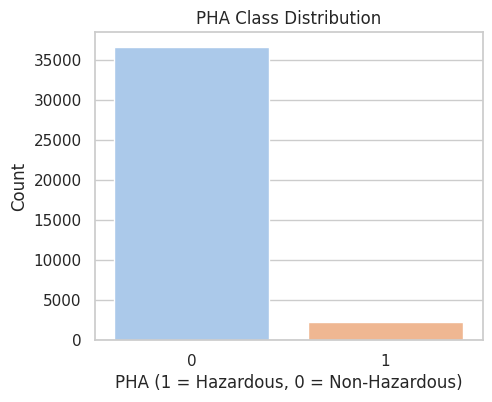

In [10]:
# Class Distribution
plt.figure(figsize=(5, 4))
sns.countplot(x=target_col, data=df, palette="pastel")
plt.title("PHA Class Distribution")
plt.xlabel("PHA (1 = Hazardous, 0 = Non-Hazardous)")
plt.ylabel("Count")
plt.show()

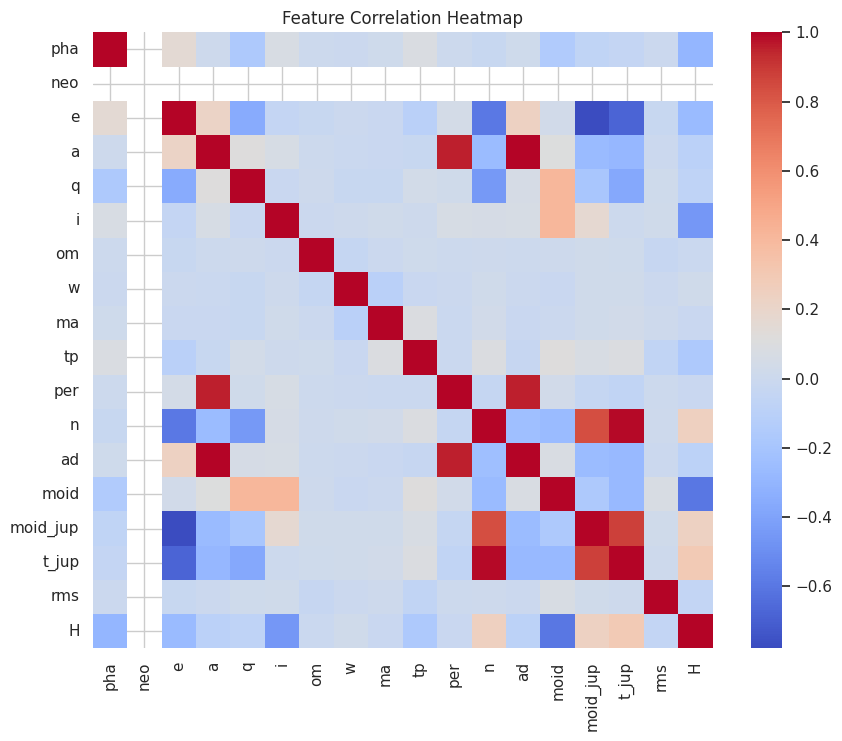

In [11]:
# Correlation Heatmap
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), cmap="coolwarm", annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()

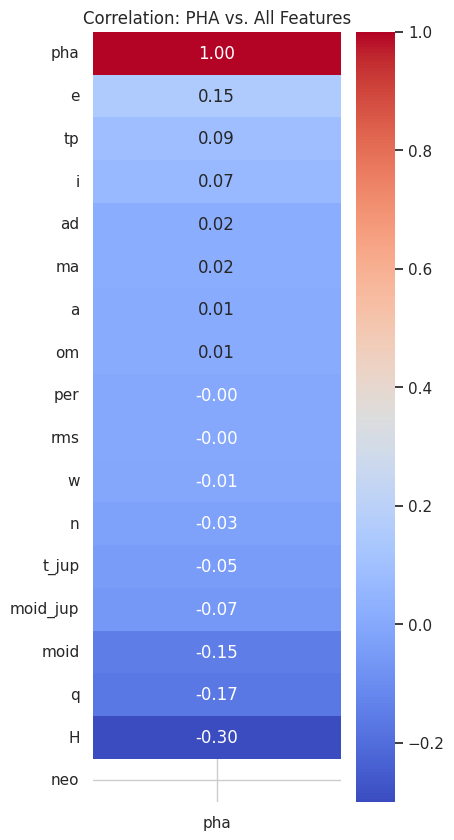

In [12]:
corr_matrix = df[numeric_cols].corr()

# Extract only the correlation of 'pha' with other columns
# Sort the values so the most important features appear at the top
pha_corr = corr_matrix[['pha']].sort_values(by='pha', ascending=False)

# Plot the single-column heatmap
plt.figure(figsize=(4, 10))
sns.heatmap(pha_corr, annot=True, cmap="coolwarm", fmt=".2f", cbar=True)
plt.title("Correlation: PHA vs. All Features")
plt.show()

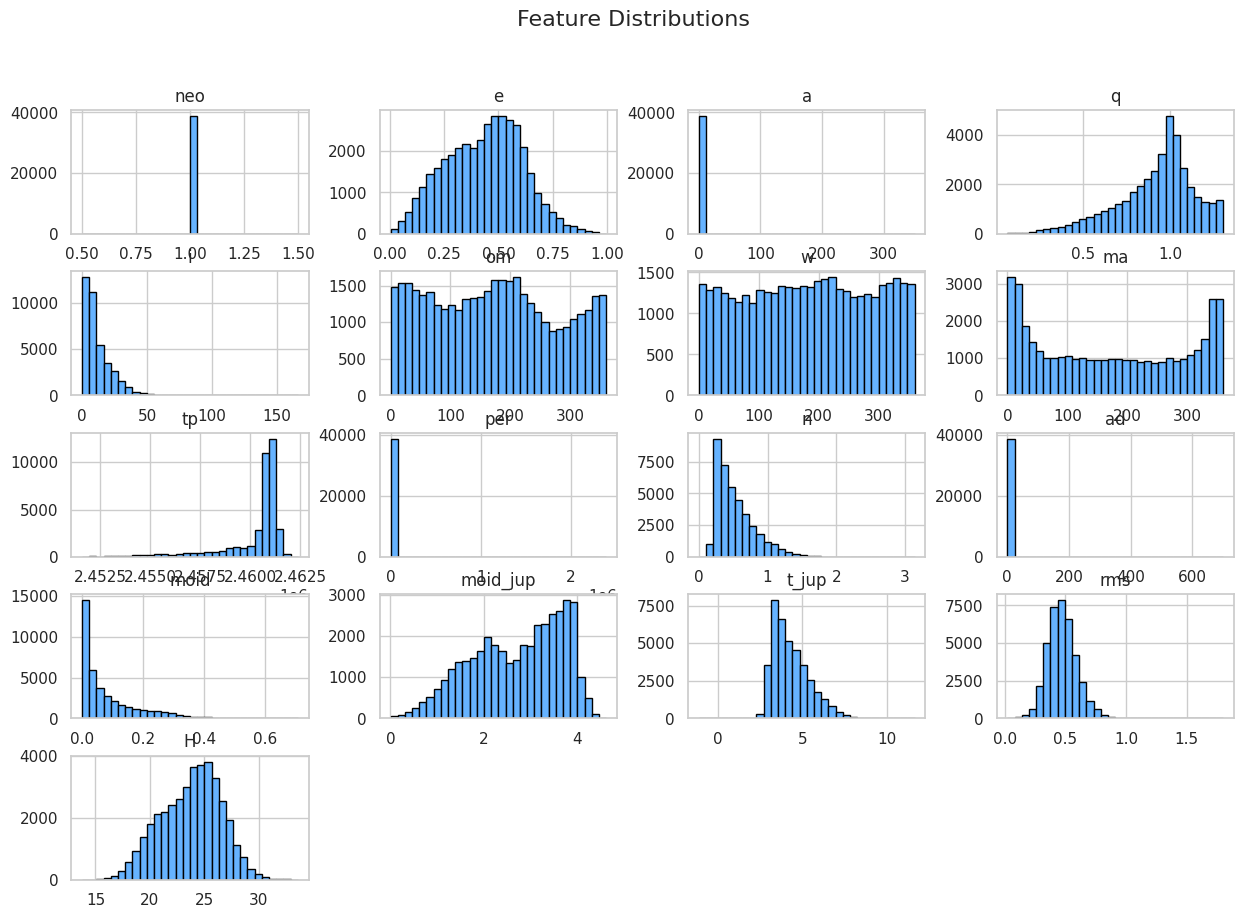

In [13]:
# Feature Distributions
num_features = [c for c in numeric_cols if c != target_col]
df[num_features].hist(figsize=(15, 10), bins=30, color="#66b3ff", edgecolor="black")
plt.suptitle("Feature Distributions", fontsize=16)
plt.show()

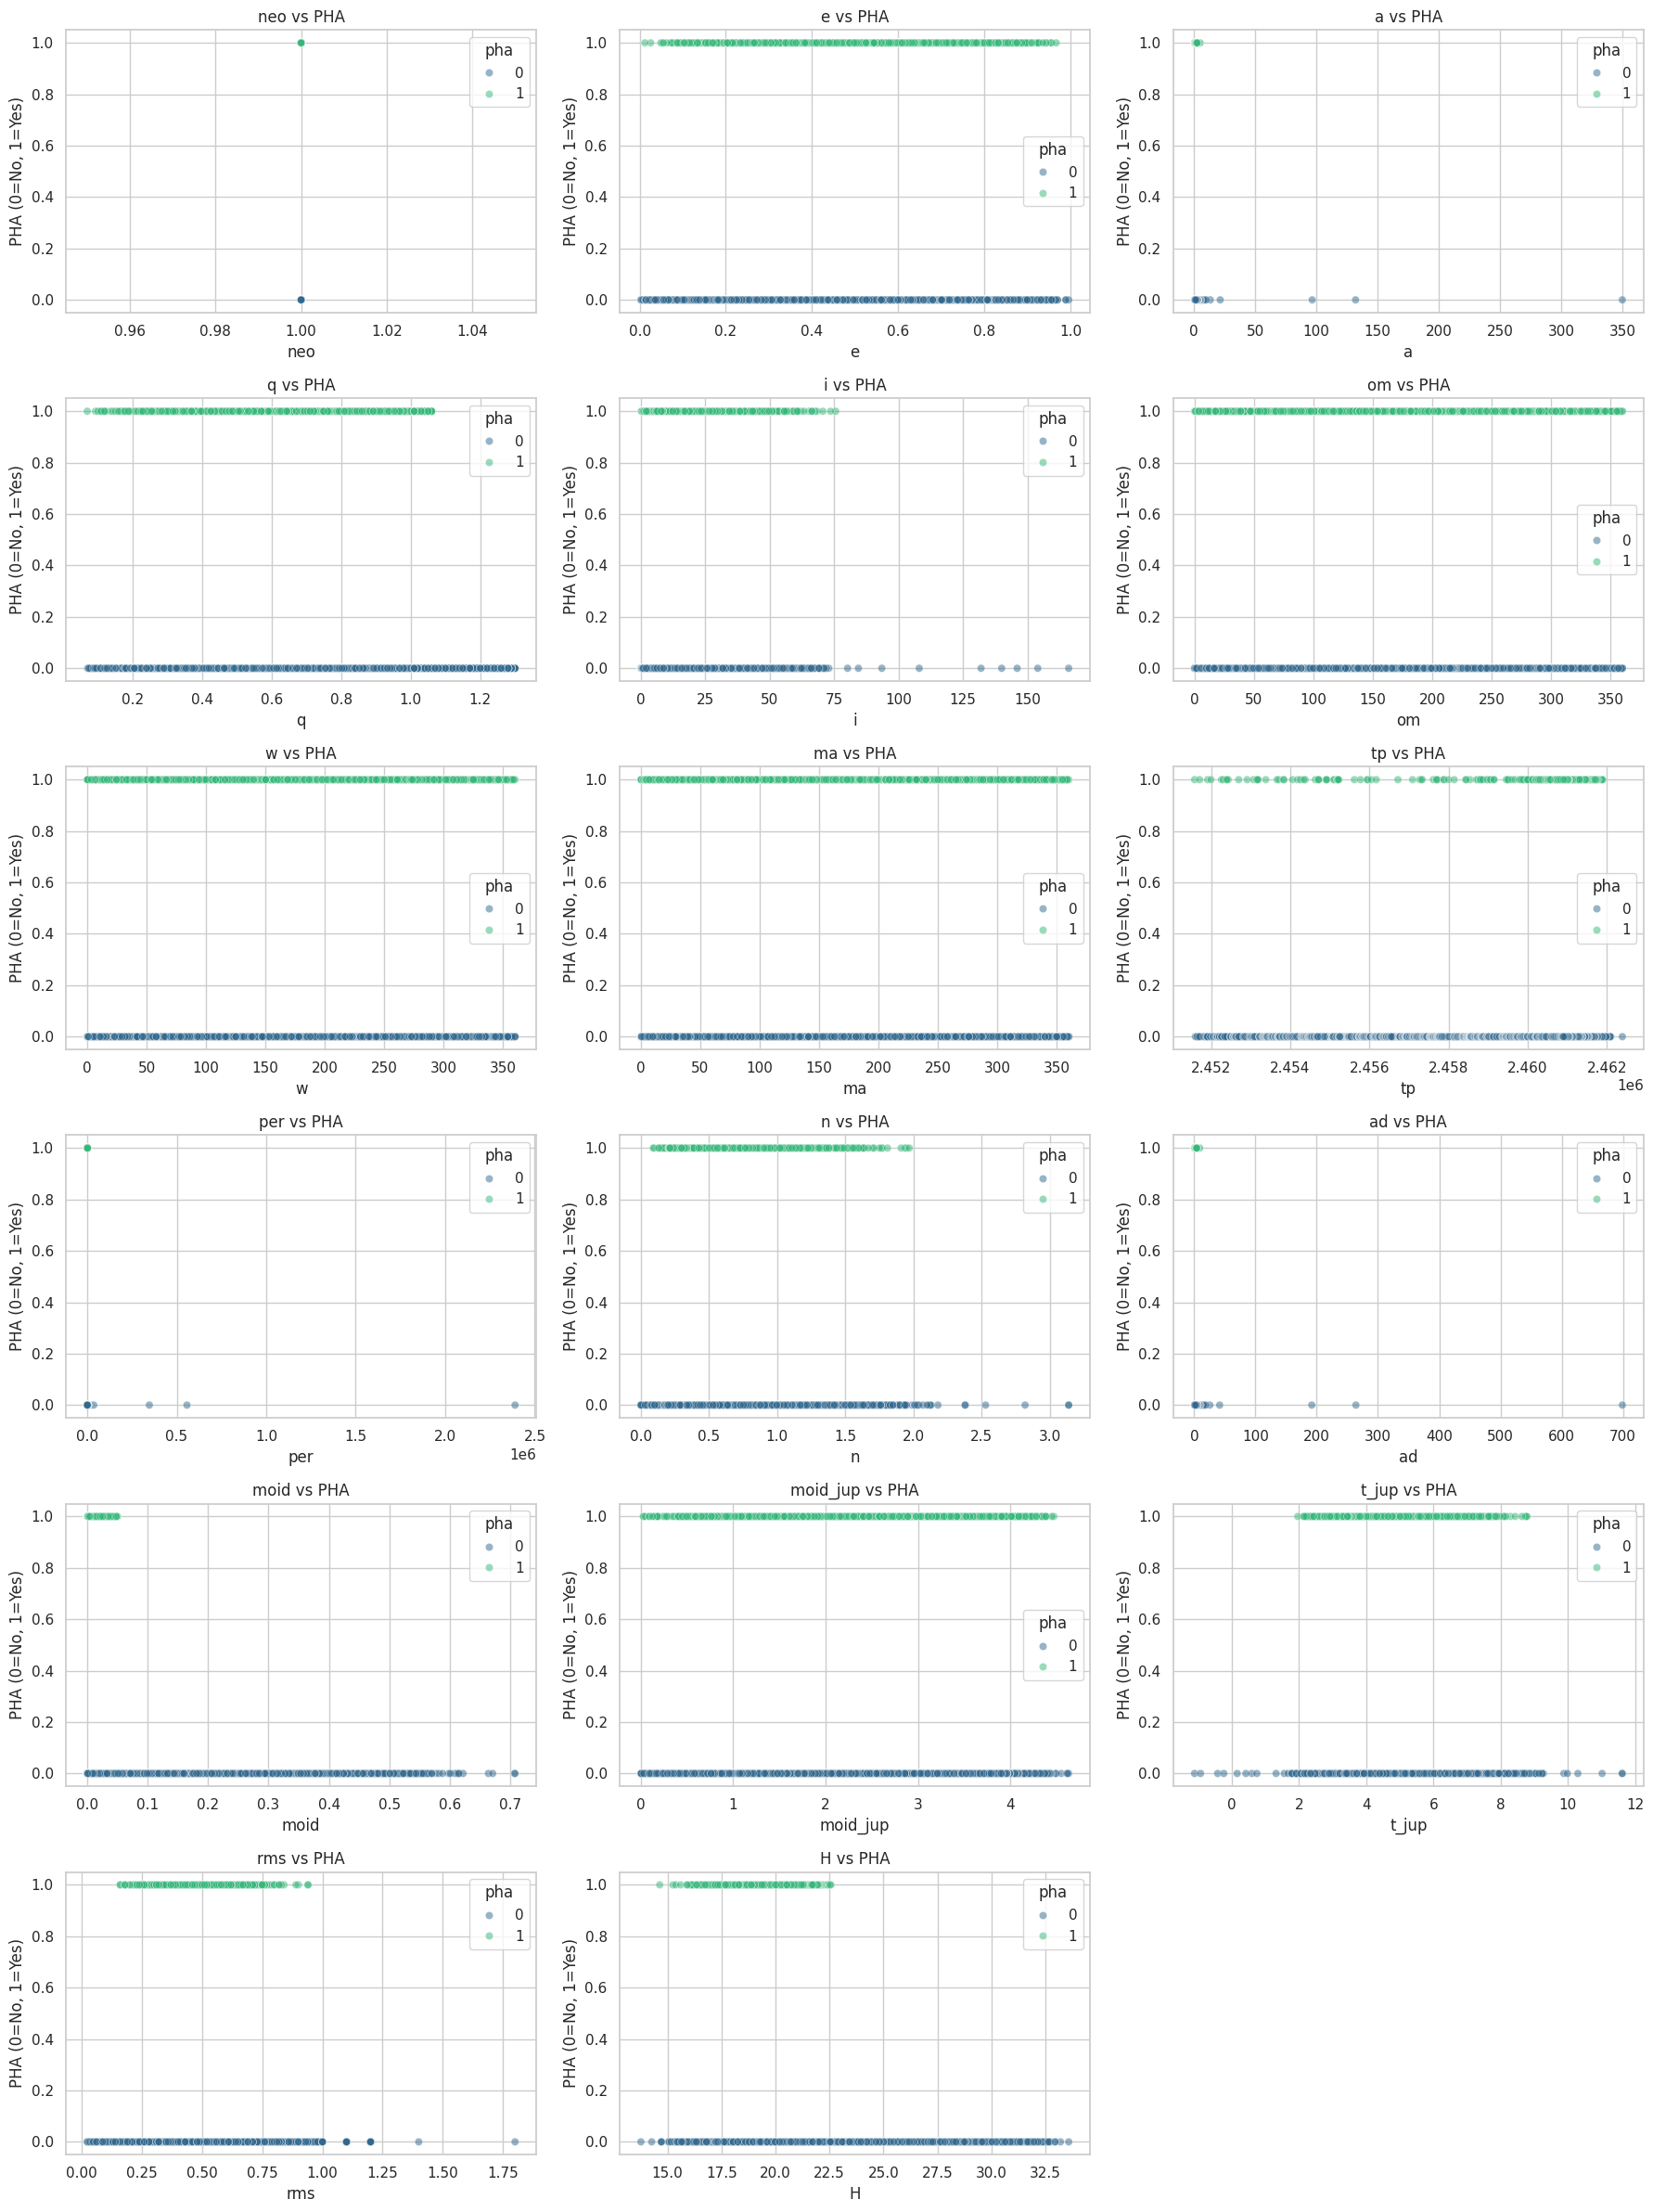

In [14]:
# Define your features (excluding the target itself and the designation)
features_to_plot = [f for f in num_features if f != 'pha']

# Create a grid of plots
cols = 3
rows = (len(features_to_plot) // cols) + 1
fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 4))
axes = axes.flatten()

for i, col in enumerate(features_to_plot):
    sns.scatterplot(data=df, x=col, y='pha', hue='pha', ax=axes[i], palette='viridis', alpha=0.5)
    axes[i].set_title(f'{col} vs PHA')
    axes[i].set_ylabel('PHA (0=No, 1=Yes)')

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

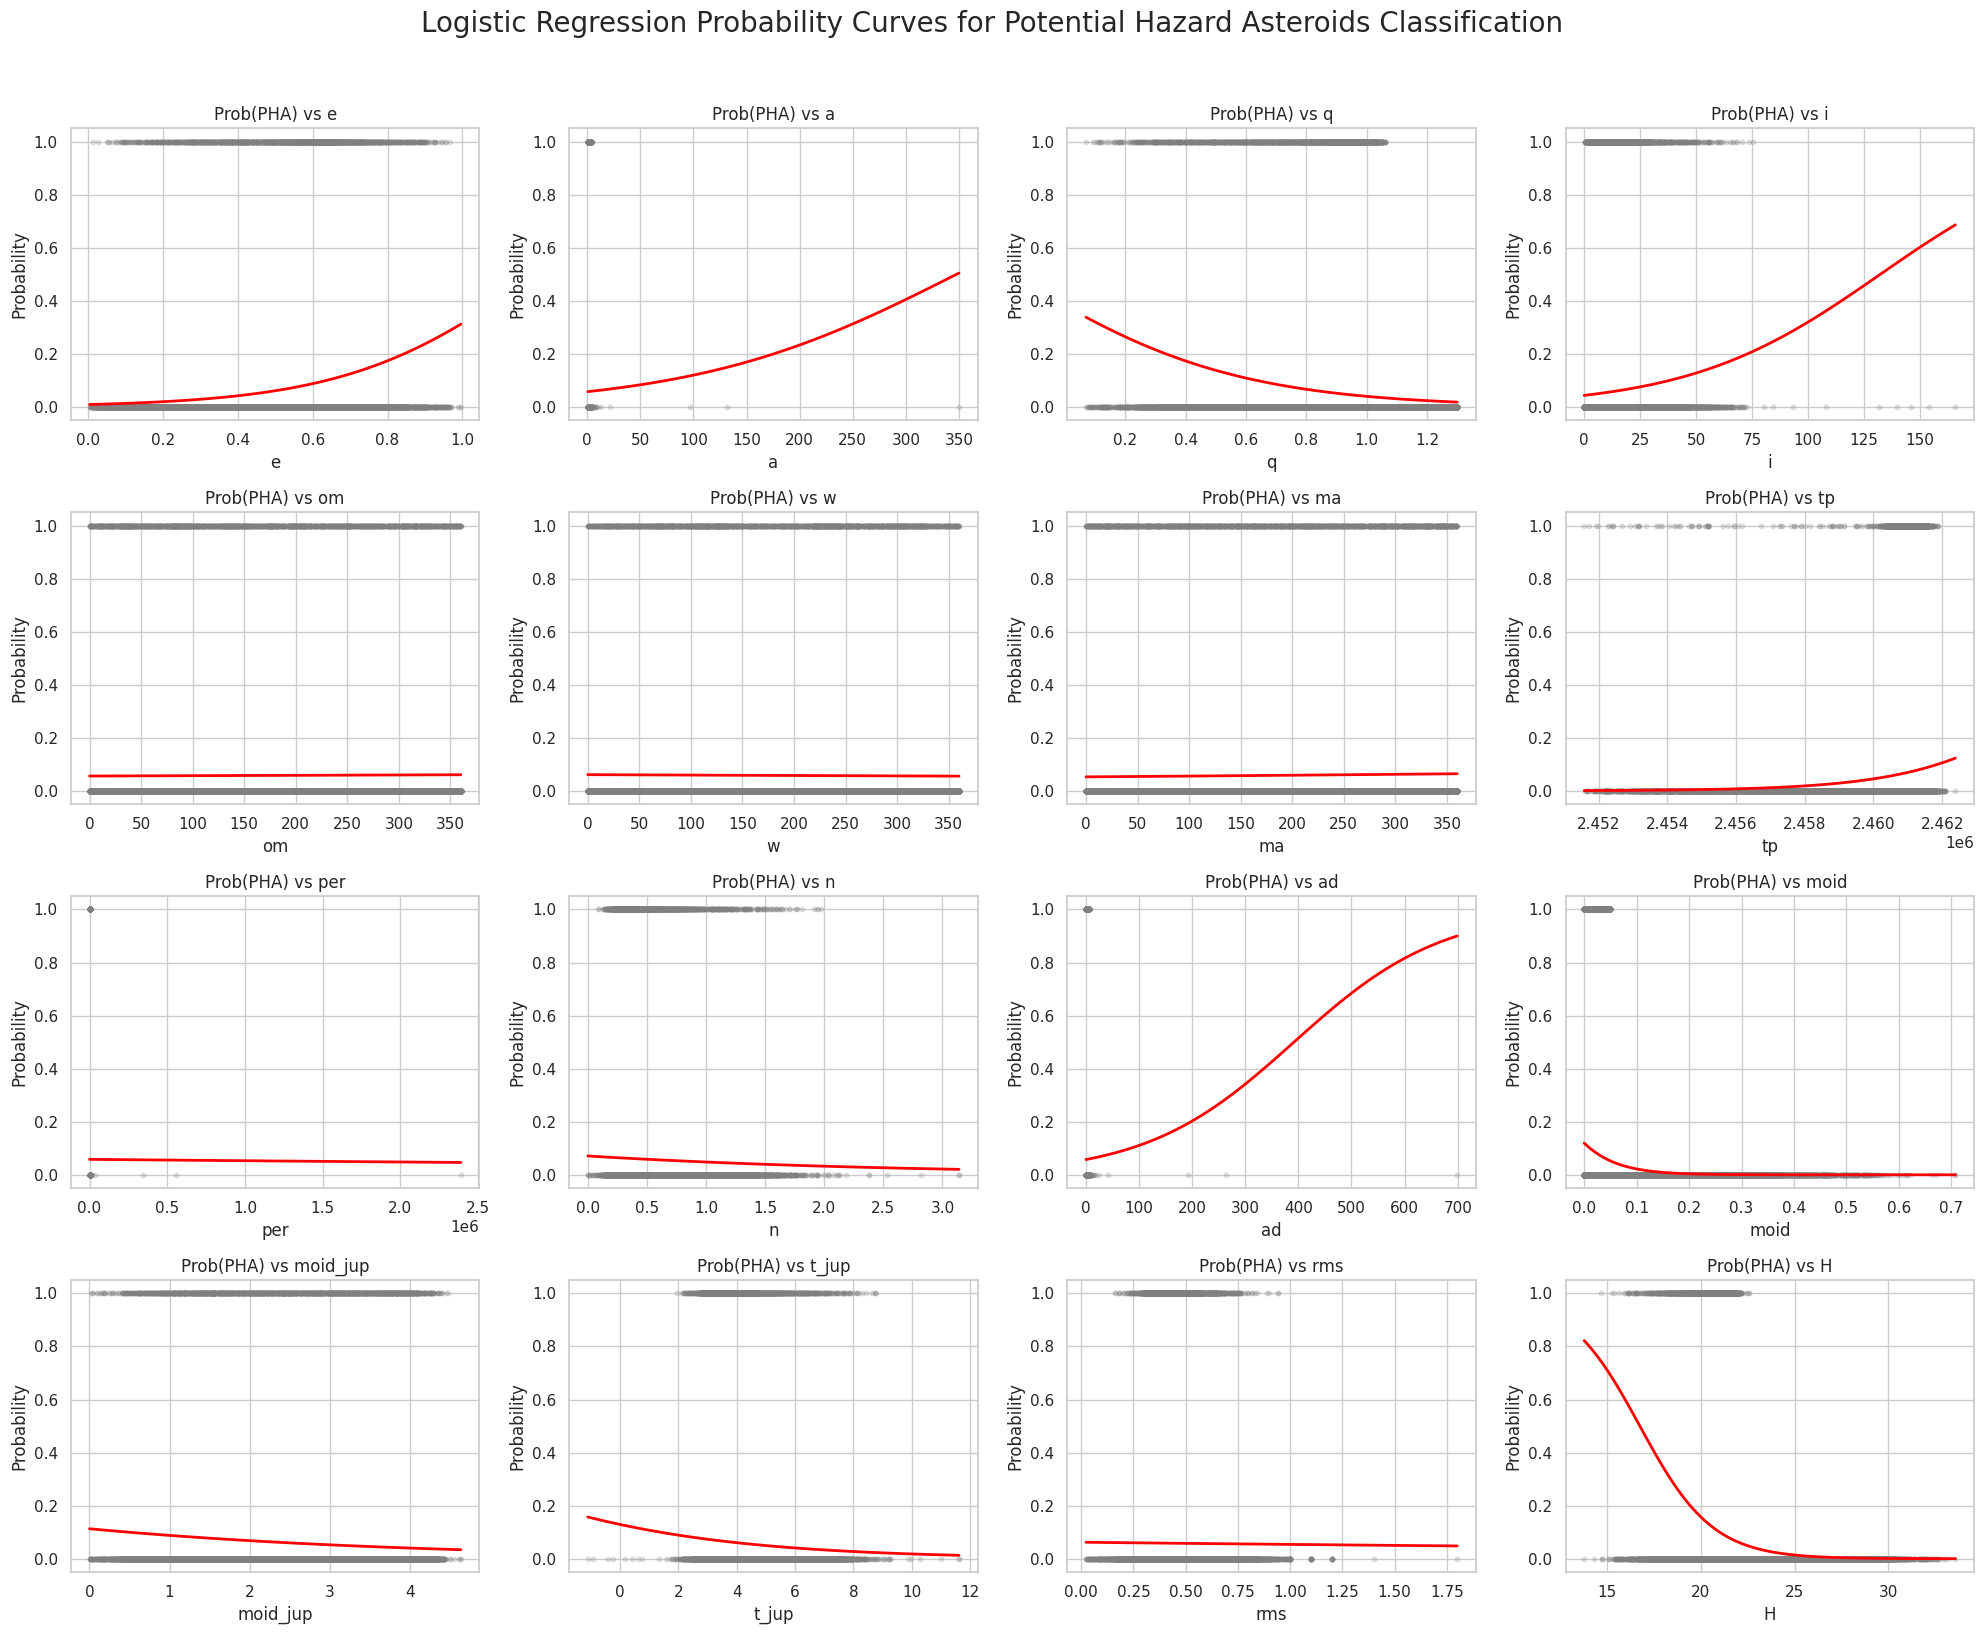

In [15]:
# Identify numerical columns (excluding non-predictive or target columns)
num_features = df.select_dtypes(include=[np.number]).columns.tolist()
# Filter out the target itself and metadata like 'neo' or identifiers
features_to_plot = [f for f in num_features if f not in ['pha', 'neo', 'des']]

# Setup the visualization grid
cols = 4
rows = (len(features_to_plot) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 4))
axes = axes.flatten()

# Generate logistic regression plots for each feature
for i, feature in enumerate(features_to_plot):
    try:
        sns.regplot(
            data=df,
            x=feature,
            y='pha',
            logistic=True,
            ci=None,
            ax=axes[i],
            scatter_kws={'alpha': 0.2, 'color': 'gray', 's': 10},
            line_kws={'color': 'red', 'linewidth': 2}
        )
        axes[i].set_title(f"Prob(PHA) vs {feature}", fontsize=12)
        axes[i].set_ylabel("Probability")
        axes[i].set_ylim(-0.05, 1.05)
    except Exception as e:
        axes[i].set_title(f"Error plotting {feature}")
        continue

# Remove any unused subplot axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Logistic Regression Probability Curves for Potential Hazard Asteroids Classification", fontsize=20, y=1.02)
plt.tight_layout()
plt.show()

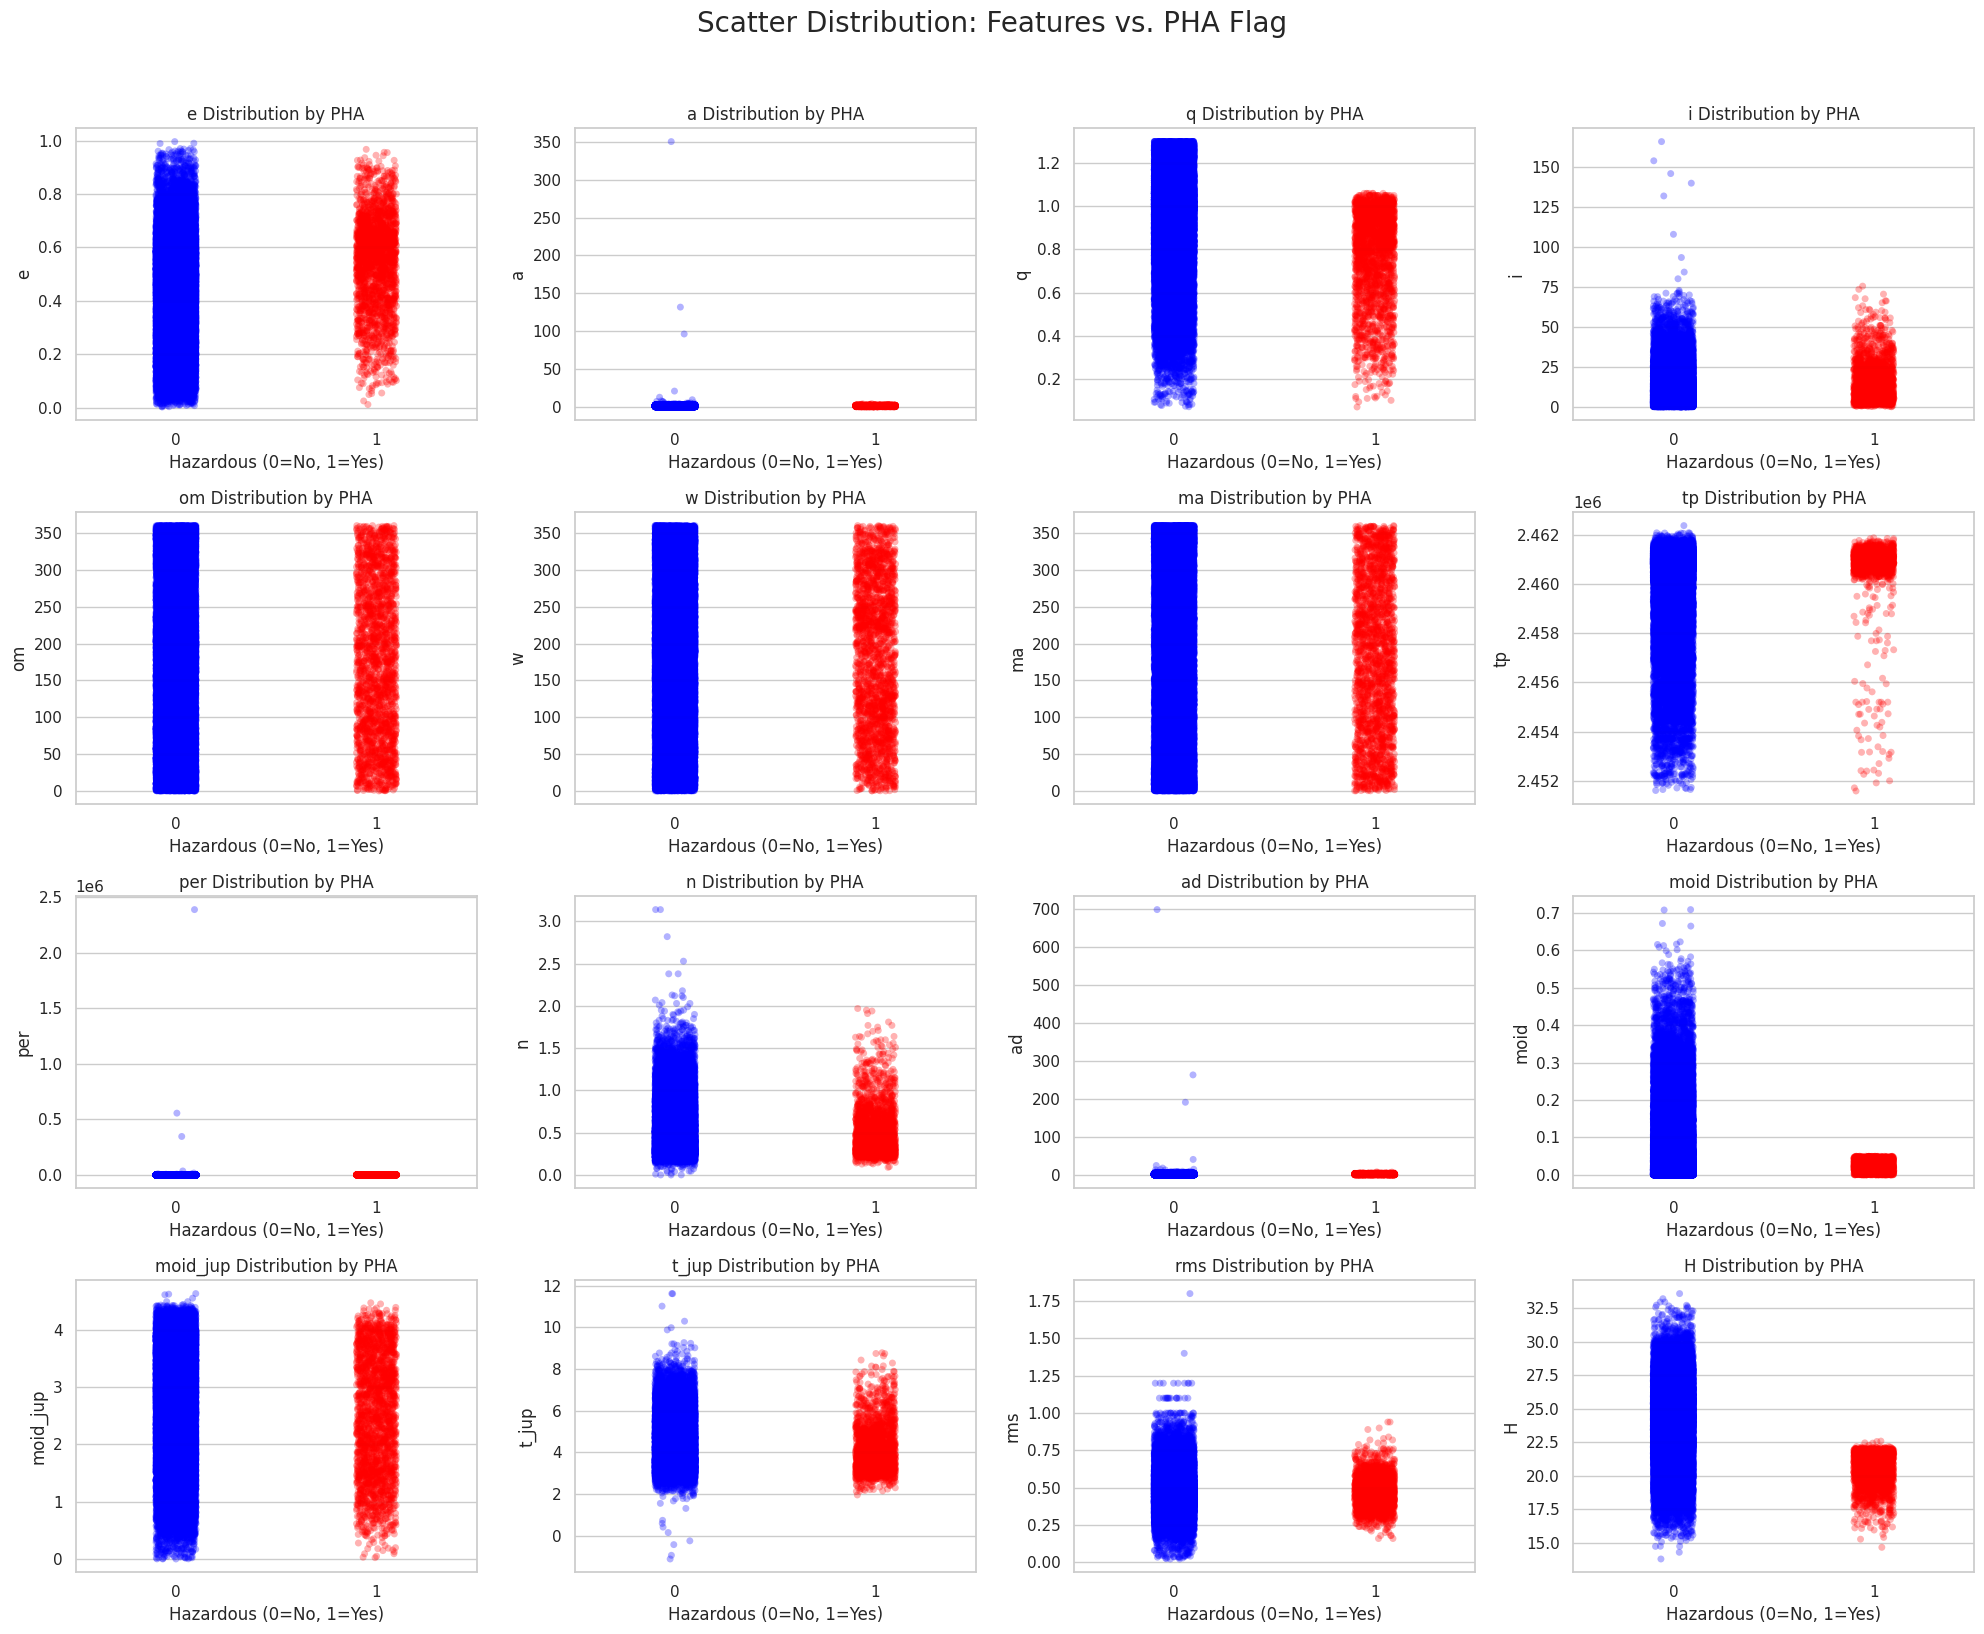

In [21]:
# Select numeric features
num_features = df.select_dtypes(include=[np.number]).columns.tolist()
features_to_plot = [f for f in num_features if f not in ['pha', 'neo', 'des']]

# Setup the grid
cols = 4
rows = (len(features_to_plot) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 4))
axes = axes.flatten()

for i, feature in enumerate(features_to_plot):
    # Stripplot shows the distribution of the two colors clearly
    sns.stripplot(data=df, x='pha', y=feature, hue='pha',
                  palette={0: "blue", 1: "red"}, alpha=0.3, ax=axes[i], jitter=True)

    axes[i].set_title(f"{feature} Distribution by PHA")
    axes[i].set_xlabel("Hazardous (0=No, 1=Yes)")
    axes[i].legend_.remove() # Remove redundant legend for each subplot

# Clean up empty plots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Scatter Distribution: Features vs. PHA Flag", fontsize=20, y=1.02)
plt.tight_layout()
plt.show()

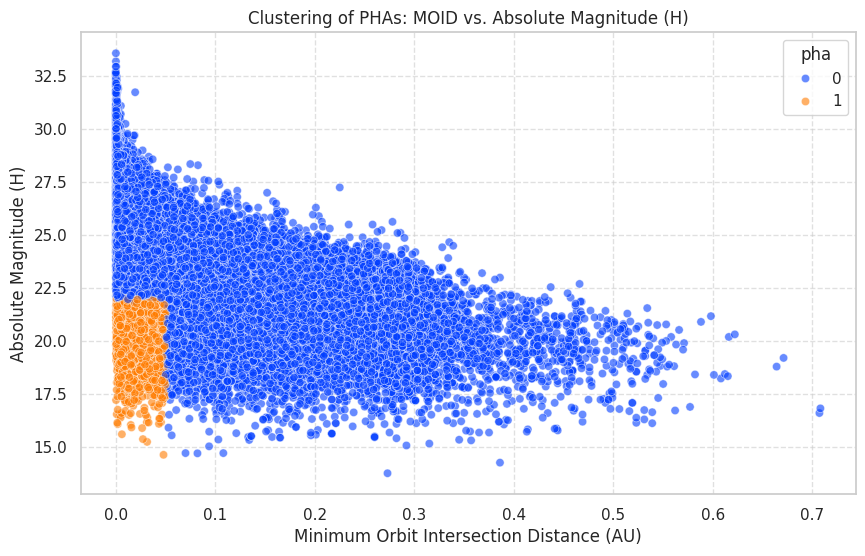

In [22]:
# Pick the two most important features from your correlation analysis
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='moid', y='H', hue='pha', palette='bright', alpha=0.6)

plt.title("Clustering of PHAs: MOID vs. Absolute Magnitude (H)")
plt.xlabel("Minimum Orbit Intersection Distance (AU)")
plt.ylabel("Absolute Magnitude (H)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

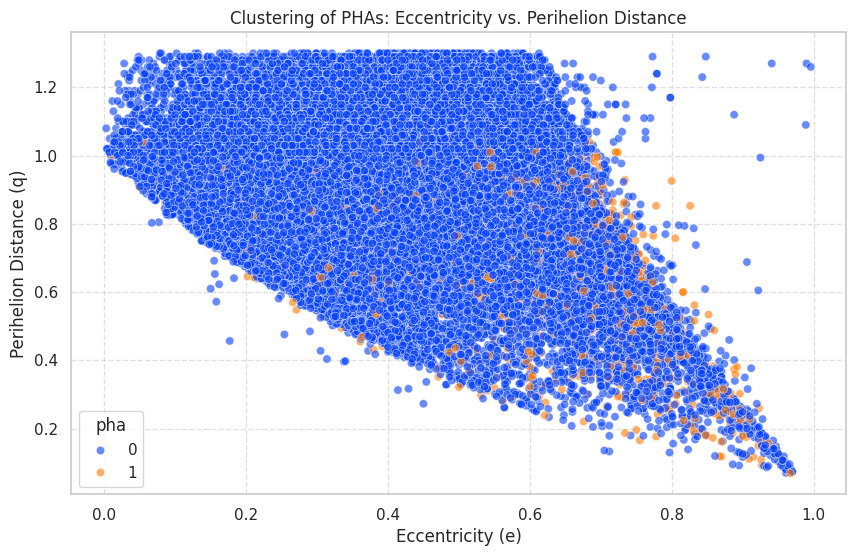

In [24]:
# Pick the two most important features from your correlation analysis
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='e', y='q', hue='pha', palette='bright', alpha=0.6)

plt.title("Clustering of PHAs: Eccentricity vs. Perihelion Distance")
plt.xlabel("Eccentricity (e)")
plt.ylabel("Perihelion Distance (q)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()